# Gaia BH3

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares

In [3]:
np.random.seed(42)

In [4]:
epoch_astrom = EpochAstrometry(primary_mass=None, gaia_release="DR4")
epoch_astrom.gaia_bh3(exclude_outliers=True, combine_ccds=False)


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

---------------
Querying source
---------------

Gaia release: DR3
Source ID: 4318465066420528000

INFO: Query finished. [astroquery.utils.tap.core]

RA = 294.828 deg +/- 0.051 mas
Dec = 14.931 deg +/- 0.052 mas
Parallax = 1.644 +/- 0.069 mas
Proper motion in RA = -22.235 +/- 0.062 mas/yr
Proper motion in Dec = -155.276 +/- 0.059 mas/yr
G-band magnitude = 11.231
Pseudocolor = 1.48 um-1

UWE = 6.18
RUWE = 3.41
Astrometric excess noise (mas) = 0.6550 +/- 0.0014
Non single star = 0

-------------------
Gaia BH3 epoch data
-------------------

Gaia release: DR4
Reference epoch: 2017.5
Source ID: 4318465066420528000

Primary mass (Msun): 0.76 +/- 0.05

Data file: /Users/tomasstolker/applications/exogaia/data/gaiabh3_epochast.dat
Data shape: (599, 12)


In [5]:
print(epoch_astrom)

          transit_id  ccd_id  obs_time_tcb  centroid_pos_al  centroid_pos_error_al  parallax_factor_al  scan_pos_angle  outlier_flag  sin_scan_ang  cos_scan_ang  relative_time_year  relative_time_day
0  20114916805338633       1   2014.820290          147.066                  0.370             0.70828      -59.046727             0     -0.857587      0.514339           -2.679710        -978.764022
1  20114916805338633       2   2014.820290          146.696                  0.231             0.70828      -59.046771             0     -0.857587      0.514338           -2.679710        -978.763966
2  20114916805338633       3   2014.820290          146.685                  0.183             0.70828      -59.046816             0     -0.857588      0.514338           -2.679710        -978.763909
3  20114916805338633       4   2014.820291          146.557                  0.151             0.70828      -59.046867             0     -0.857588      0.514337           -2.679709        -978.763844


In [6]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)

In [7]:
aen = leastsq.calc_excess_noise()


------------------------
Astrometric excess noise
------------------------

Number of iterations = 4
Number of function evaluations = 12
Number of Jacobian evaluations: 6

Astrometric excess noise (mas) = 6.7798 +/- 0.0040



--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 3090.339
RUWE = 30.709
F2 estimator = 701.387
Inflation factor = 55.622

Best-fit parameters:
   - RA offset = 1.506 +/- 0.053 mas
   - Dec offset = -0.033 +/- 0.050 mas
   - Parallax = 0.715 +/- 0.065 mas
   - mu in RA = -30.297 +/- 0.036 mas/yr
   - mu in Dec = -148.622 +/- 0.032 mas/yr


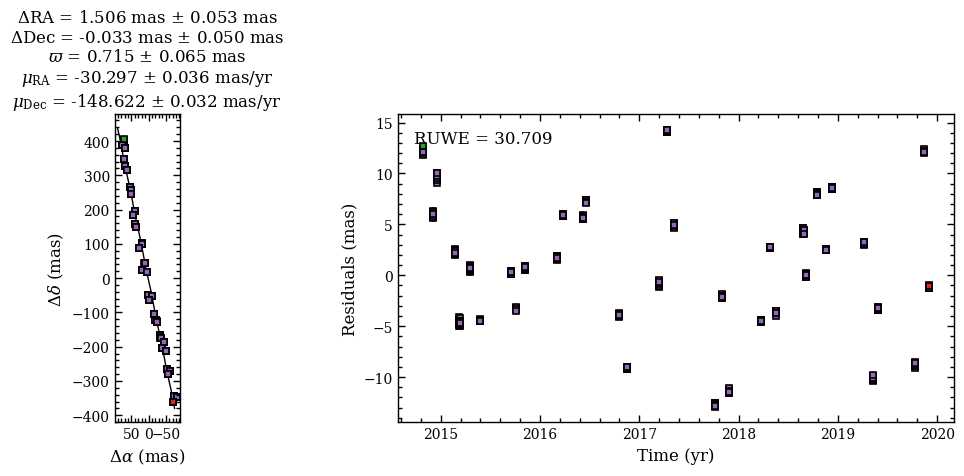

In [8]:
fig = leastsq.singl_5param(plot_file='plot.png')

In [9]:
print(leastsq)

LeastSquares(Δα = 1.50624 mas, Δδ = -0.0334119 mas, ϖ = 0.7152 mas, μ_α = -30.2968 mas/yr, μ_δ = -148.622 mas/yr)



--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 0.568

Stellar track:
   - RA offset (mas) = 4.000 +/- 0.018
   - Dec offset (mas) = 2.666 +/- 0.015
   - Parallax (mas) = 1.680 +/- 0.009
   - mu in RA (mas/yr) = -28.148 +/- 0.017
   - mu in Dec (mas/yr) = -155.590 +/- 0.014

Thiele-Innes elements:
   - Period (days) = 4520.354
   - Eccentricity = 0.733
   - Relative time of periastron = 0.05
   - Thiele-Innes A = 2.480 +/- 0.024
   - Thiele-Innes B = 11.284 +/- 0.028
   - Thiele-Innes F = 21.781 +/- 0.030
   - Thiele-Innes G = -17.708 +/- 0.033

Derived parameters:
   - Semi-major axis of photocenter (mas) = 28.618 +/- 0.029
   - Relative semi-major axis (au) = 81.728
   - Mass function (Msun) = 32.287
   - Secondary mass (Msun) = 33.757

Campbell elements:
   - Period = 4520.354 days
   - Eccentricity = 0.733
   - Relative time of periastron = 0.053
   - Semi-major axis of photocenter (mas) = 28.618
   - Inclination (deg) = 110.714
   - Argument of periastron (deg) = 77.993
   - PA of ascending node (deg) = 136.586

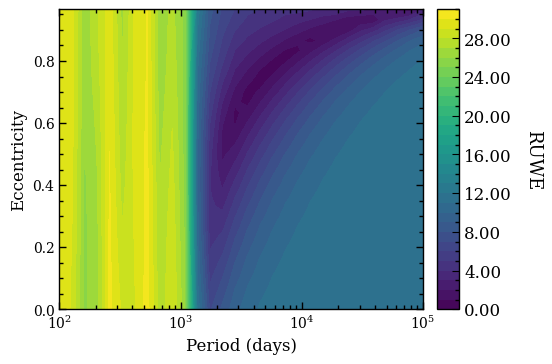

In [10]:
fig = leastsq.orbit_grid(plot_file='plot.png', n_points=30)

In [11]:
print(leastsq)

LeastSquares(Δα = 4.0005 mas, Δδ = 2.66644 mas, ϖ = 1.67976 mas, μ_α = -28.1485 mas/yr, μ_δ = -155.59 mas/yr, P = 4520.35 days, e = 0.733333, τ = 0.0533333, a = 28.6183 mas, i = 1.93232 rad, ω = 1.36124 rad, Ω = 2.38388 rad)



-------------------------
Orbit fit (12 parameters)
-------------------------

Number of function evaluations: 15
Number of Jacobian evaluations: 14

Reduced chi^2: 0.515
RUWE: 0.396

Best-fit parameters:
   - RA offset (mas) = 4.266 +/- 0.080
   - Dec offset (mas) = 2.417 +/- 0.113
   - Parallax (mas) = 1.688 +/- 0.013
   - mu in RA (mas/yr) = -28.326 +/- 0.101
   - mu in Dec (mas/yr) = -155.190 +/- 0.167
   - Period (days) = 4232.934 +/- 146.810
   - Eccentricity = 0.728 +/- 0.007
   - Relative time of periastron = 0.057 +/- 0.002
   - Semi-major axis (mas) = 27.283 +/- 0.736
   - Inclination (deg) = 110.559 +/- 0.139
   - Argument of periastron (deg) = 77.835 +/- 0.221
   - PA of ascending node (deg) = 136.188 +/- 0.192
   - Jitter (mas) = 0.105 +/- 0.001


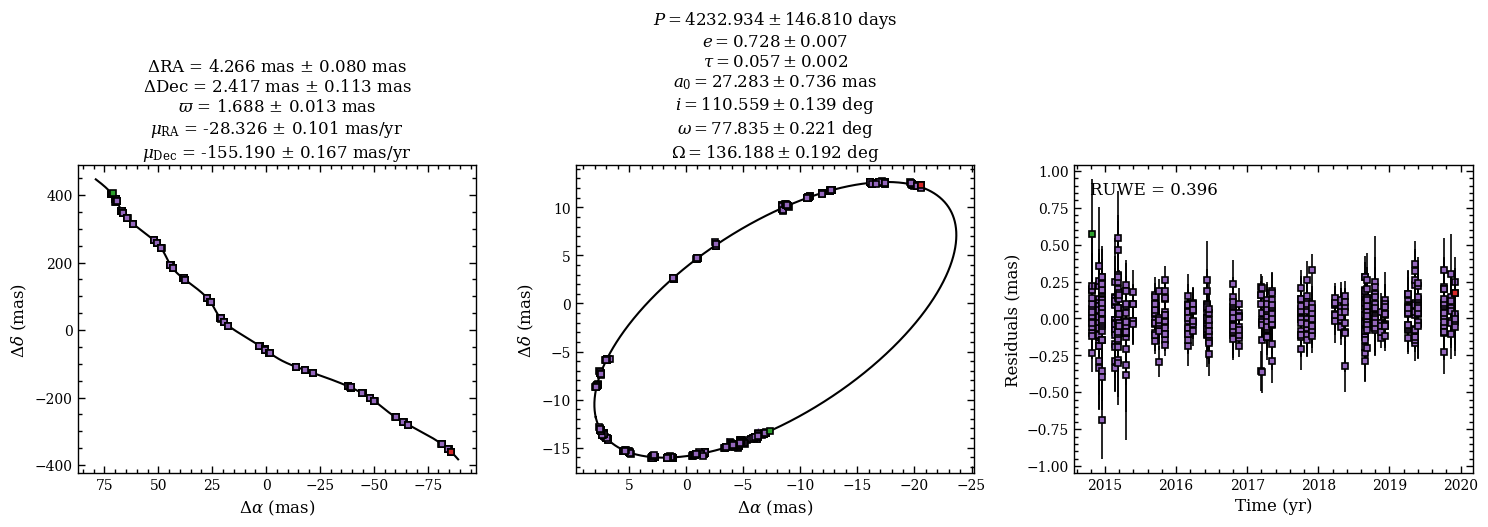

In [12]:
fig = leastsq.orbit_fit(inc_jitter=True, plot_file='plot.png')

In [13]:
print(leastsq)

LeastSquares(Δα = 4.26642 mas, Δδ = 2.41716 mas, ϖ = 1.6877 mas, μ_α = -28.3259 mas/yr, μ_δ = -155.19 mas/yr, P = 4232.93 days, e = 0.728362, τ = 0.0568078, a = 27.2834 mas, i = 1.92961 rad, ω = 1.35848 rad, Ω = 2.37693 rad)
